# CP-GEN

This notebook predicts genome-level SNP counts.

**Approach:**
- Load population clusters from K-Means (k=5)
- For each cluster, perform leave-one-out validation
- Train models: Linear Regression, Random Forest, SVR
- Predict genome-level SNP count of target gene  using other genes as features
- Evaluate with RMSE and MAE

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from os.path import join
from pathlib import Path
import numpy as np
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore')
import sys
from mylib import genomes


In [3]:
population_dict = {
    "ASW": "African Ancestry, USA",
    "ACB": "African Caribbean, Barbados",
    "BEB": "Bengali, Bangladesh",
    "GBR": "British, England and Scotland",
    "CDX": "Chinese Dai, China",
    "CLM": "Colombian, Colombia",
    "ESN": "Esan, Nigeria",
    "FIN": "Finnish, Finland",
    "GWD": "Gambian Mandinka, Gambia",
    "GIH": "Gujarati Indian, USA",
    "CHB": "Han Beijing, China",
    "CHS": "Han South, China",
    "IBS": "Iberian, Spain",
    "ITU": "Indian Telugu, UK",
    "JPT": "Japanese, Japan",
    "KHV": "Kinh, Vietnam",
    "LWK": "Luhya, Kenya",
    "MSL": "Mende, Sierra Leone",
    "MXL": "Mexican Ancestry, USA",
    "PEL": "Peruvian, Peru",
    "PUR": "Puerto Rican, Puerto Rico",
    "PJL": "Punjabi, Pakistan",
    "STU": "Sri Lankan Tamil, UK",
    "TSI": "Toscani, Italy",
    "YRI": "Yoruba, Nigeria"
}

In [4]:
# Configuration
als_root_dir = join(Path.home(), "projects/cp_als/populations")
cluster_file = "als_population2cluster_AggCluster_k5.csv"
target_gene = "TARDBP" # "SOD1" # "FUS", "TARDBP"

major_genes = ["TARDBP", "FUS", "SOD1", "CHMP2B"]
removed_genes = [g for g in major_genes if g != target_gene]

print(f"ALS data directory: {als_root_dir}")
print(f"Cluster file: {cluster_file}")
print(f"Target gene: {target_gene}")
print(f"Removed genes: {removed_genes}")

ALS data directory: /Users/lhvu/projects/cp_als/populations
Cluster file: als_population2cluster_AggCluster_k5.csv
Target gene: TARDBP
Removed genes: ['FUS', 'SOD1', 'CHMP2B']


## Load Population Clusters

In [5]:
# Load cluster assignments
cluster_df = pd.read_csv(cluster_file)
print("Cluster assignments:")
print(cluster_df.head(10))

# Group populations by cluster
clusters = {}
for cluster_id in sorted(cluster_df['Cluster'].unique()):
    pops = cluster_df[cluster_df['Cluster'] == cluster_id]['Population'].tolist()
    clusters[cluster_id] = pops
    print(f"\nCluster {cluster_id}: {len(pops)} populations")
    print(f"  {', '.join(pops)}")

Cluster assignments:
   Index Population  Cluster
0      1        ACB        1
1      2        ASW        1
2      3        BEB        4
3      4        CDX        2
4      5        CHB        2
5      6        CHS        2
6      7        CLM        0
7      8        ESN        1
8      9        FIN        3
9     10        GBR        3

Cluster 0: 4 populations
  CLM, MXL, PEL, PUR

Cluster 1: 7 populations
  ACB, ASW, ESN, GWD, LWK, MSL, YRI

Cluster 2: 5 populations
  CDX, CHB, CHS, JPT, KHV

Cluster 3: 4 populations
  FIN, GBR, IBS, TSI

Cluster 4: 5 populations
  BEB, GIH, ITU, PJL, STU


## Helper Functions

In [6]:
def get_df_list(population_names, data_dir):
    """Load data for multiple populations"""
    als_df_list = list()
    for population_name in population_names:
        odf = pd.read_csv(join(data_dir, f"output/{population_name}/all.csv"))
        odf = odf[genomes[population_name] + ["gene"]]
        sdf = odf.groupby(['gene']).sum()
        # sdf = odf.groupby(['gene']).mean()
        als_df_list.append(sdf.transpose())
    return als_df_list

def get_als_data_frames(population_names, als_root_dir):
    """Concatenate data frames for multiple populations"""
    als_df = pd.concat(get_df_list(
        population_names=population_names,
        data_dir=als_root_dir,
    ))
    return als_df

def build_model_als(model, gene_name, remaining_genes, train_df, test_df):
    """Train and evaluate a model for a specific gene"""
    y_train = train_df[[gene_name]].values
    X_train = train_df[remaining_genes].values
    y_test = test_df[[gene_name]].values
    X_test = test_df[remaining_genes].values
    
    # Fit scalers only on training data
    x_scaler = StandardScaler()
    y_scaler = StandardScaler()
    
    X_train_scaled = x_scaler.fit_transform(X_train)
    y_train_scaled = y_scaler.fit_transform(y_train).ravel()

    # Apply same transform to test data
    X_test_scaled = x_scaler.transform(X_test)
    y_test_scaled = y_scaler.transform(y_test).ravel()

    model.fit(X_train_scaled, y_train_scaled)
    y_pred_scaled = model.predict(X_test_scaled)

    # Compute metrics in scaled space
    rmse_scaled = np.sqrt(mean_squared_error(y_test_scaled, y_pred_scaled))
    mae_scaled = mean_absolute_error(y_test_scaled, y_pred_scaled)

    res = {
        "gene": gene_name,
        "model": model.__class__.__name__,
        "rmse": rmse_scaled,
        "mae": mae_scaled
    }
    
    return res

In [7]:
# Define cluster labels
cluster_labels = {
    0: 'American (4 pops)',
    1: 'African (7 pops)',
    2: 'East Asian (5 pops)',
    3: 'European (4 pops)',
    4: 'South Asian (5 pops)'
}

## Prepare to build

In [8]:
# Define models
models = [
    LinearRegression(),
    RandomForestRegressor(n_estimators=1000, random_state=42, n_jobs=-1),
    SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1),
]

print(f"Models to test: {[m.__class__.__name__ for m in models]}")

Models to test: ['LinearRegression', 'RandomForestRegressor', 'SVR']


In [9]:
# Store results
results = []

print(f"\nRunning cluster-based leave-one-out for {target_gene}...\n")

# For each cluster
for cluster_id, population_names in clusters.items():
    print(f"\n{'='*80}")
    print(f"Cluster {cluster_id}: {len(population_names)} populations")
    print(f"{'='*80}")
    
    # For each population in the cluster (leave-one-out)
    for pname in population_names:
        print(f"\nTest population: {pname} ({population_dict[pname]})")
        
        # Define train and test populations
        testing_population_names = [pname]
        training_population_names = [item for item in population_names if item != pname]
        
        # Load data
        als_train_df = get_als_data_frames(
            population_names=training_population_names,
            als_root_dir=als_root_dir,
        )
        als_test_df = get_als_data_frames(
            population_names=testing_population_names,
            als_root_dir=als_root_dir,
        )
        
        # Get gene names
        gene_name = target_gene
        remaining_genes = [g for g in list(als_train_df.columns) if g != gene_name and g not in removed_genes]
        print(f"number of remain: {len(remaining_genes)}")
        print(remaining_genes, gene_name)
        
        # Train and evaluate each model
        for model in models:
            try:
                res = build_model_als(model, gene_name, remaining_genes, 
                                     als_train_df, als_test_df)
                res['cluster'] = cluster_id
                res['test_population'] = pname
                results.append(res)
                
                print(f"  {model.__class__.__name__}: RMSE={res['rmse']:.4f}, MAE={res['mae']:.4f}")
            except Exception as e:
                print(f"  {model.__class__.__name__}: Error - {e}")

# Convert to DataFrame
results_df = pd.DataFrame(results)
print(f"\n\nTotal experiments: {len(results_df)}")
results_df.head(10)


Running cluster-based leave-one-out for TARDBP...


Cluster 0: 4 populations

Test population: CLM (Colombian, Colombia)
number of remain: 32
['ALS2', 'ANG', 'ATXN2', 'C19ORF12', 'C9ORF72', 'CHCHD10', 'CHRNA3', 'CREST', 'DAO', 'DCTN1', 'ELP3', 'ERBB4', 'EWSR1', 'FIG4', 'MATR3', 'NEFH', 'NEK1', 'OPTN', 'PFN1', 'PNPLA6', 'PON1-3', 'PRPH', 'SETX', 'SIGMAR1', 'SPG11', 'SQSTM1', 'TAF15', 'TUBA4A', 'VAPB', 'VCP', 'hnRNPA2B1', 'hnRNPa1'] TARDBP
  LinearRegression: RMSE=1.3387, MAE=0.7867
  RandomForestRegressor: RMSE=1.3029, MAE=0.7041
  SVR: RMSE=1.1730, MAE=0.5230

Test population: MXL (Mexican Ancestry, USA)
number of remain: 32
['ALS2', 'ANG', 'ATXN2', 'C19ORF12', 'C9ORF72', 'CHCHD10', 'CHRNA3', 'CREST', 'DAO', 'DCTN1', 'ELP3', 'ERBB4', 'EWSR1', 'FIG4', 'MATR3', 'NEFH', 'NEK1', 'OPTN', 'PFN1', 'PNPLA6', 'PON1-3', 'PRPH', 'SETX', 'SIGMAR1', 'SPG11', 'SQSTM1', 'TAF15', 'TUBA4A', 'VAPB', 'VCP', 'hnRNPA2B1', 'hnRNPa1'] TARDBP
  LinearRegression: RMSE=1.4586, MAE=0.8331
  RandomForestRegresso

,gene,model,rmse,mae,cluster,test_population
0,TARDBP,LinearRegression,1.338721,0.786716,0,CLM
1,TARDBP,RandomForestRegressor,1.302932,0.704087,0,CLM
2,TARDBP,SVR,1.172957,0.522952,0,CLM
3,TARDBP,LinearRegression,1.458634,0.833118,0,MXL
4,TARDBP,RandomForestRegressor,1.427807,0.790328,0,MXL
5,TARDBP,SVR,1.381934,0.687465,0,MXL
6,TARDBP,LinearRegression,0.756427,0.476839,0,PEL
7,TARDBP,RandomForestRegressor,0.718098,0.344727,0,PEL
8,TARDBP,SVR,0.650914,0.279098,0,PEL
9,TARDBP,LinearRegression,1.064215,0.736031,0,PUR


## Save Results

In [10]:
# Save detailed results
# results_df.to_csv(f'k5_cluster_{target_gene}_prediction_detailed.csv', index=False)
print(f"Detailed results saved to: k5_cluster_{target_gene}_prediction_detailed.csv")

# Calculate summary statistics by cluster and model
summary_df = results_df.groupby(['cluster', 'model']).agg({
    'rmse': ['mean', 'std'],
    'mae': ['mean', 'std']
}).reset_index()

summary_df.columns = ['cluster', 'model', 'rmse_mean', 'rmse_std', 'mae_mean', 'mae_std']
# summary_df.to_csv(f'k5_cluster_{target_gene}_prediction_summary.csv', index=False)
print(f"Summary results saved to: k5_cluster_{target_gene}_prediction_summary.csv")

print("\nSummary:")
print(summary_df)

Detailed results saved to: k5_cluster_TARDBP_prediction_detailed.csv
Summary results saved to: k5_cluster_TARDBP_prediction_summary.csv

Summary:
    cluster                  model  rmse_mean  rmse_std  mae_mean   mae_std
0         0       LinearRegression   1.154499  0.312542  0.708176  0.159240
1         0  RandomForestRegressor   1.152720  0.309418  0.643786  0.202526
2         0                    SVR   1.036984  0.313861  0.520588  0.174538
3         1       LinearRegression   1.029899  0.148754  0.744540  0.057143
4         1  RandomForestRegressor   1.048576  0.141657  0.766170  0.061582
5         1                    SVR   1.011149  0.144906  0.738289  0.057084
6         2       LinearRegression   1.034489  0.427323  0.681446  0.200592
7         2  RandomForestRegressor   1.055355  0.446271  0.697211  0.205597
8         2                    SVR   0.982377  0.435986  0.631682  0.195881
9         3       LinearRegression   1.044976  0.331343  0.527924  0.086855
10        3  Rando

## Visualization

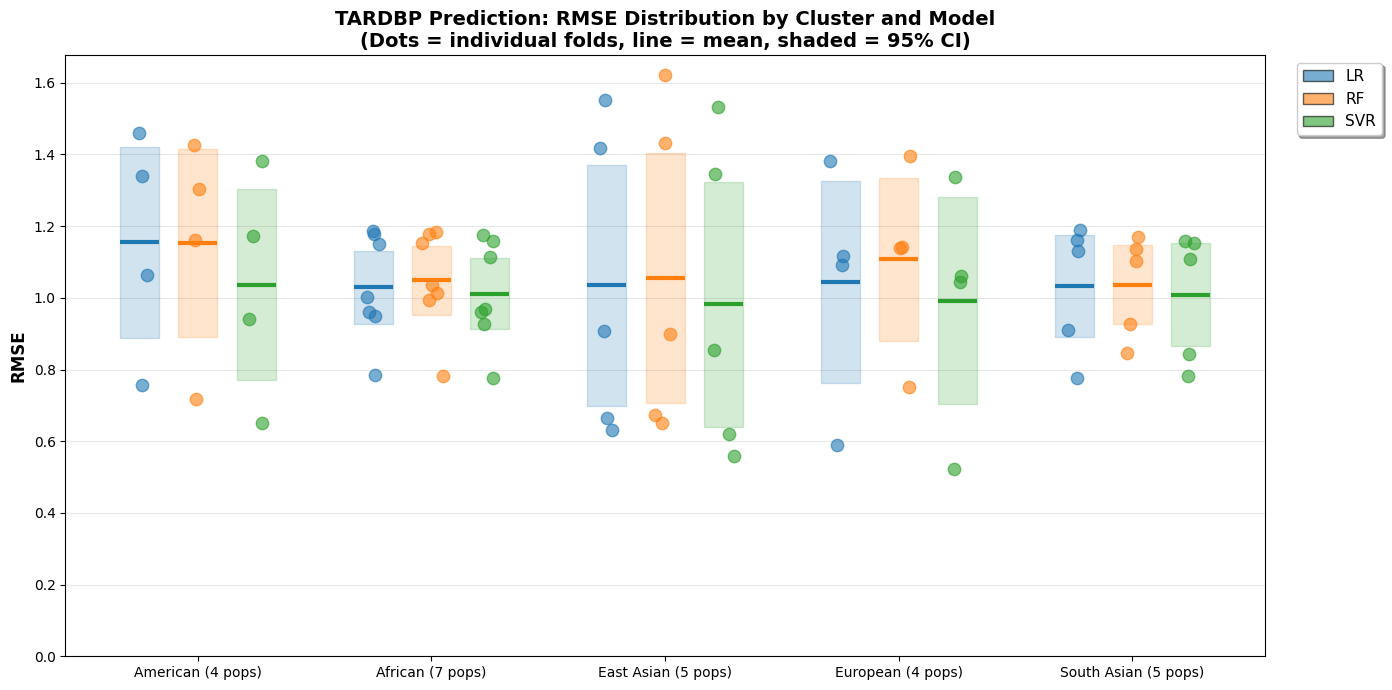

In [11]:
# Plot RMSE with Distribution (Dot Plot + Mean + CI)
fig, ax = plt.subplots(figsize=(14, 7))

# Color scheme for RMSE plot
rmse_colors = {'LinearRegression': '#1f77b4', 'RandomForestRegressor': '#ff7f0e', 'SVR': '#2ca02c'}
model_labels = {'LinearRegression': 'LR', 'RandomForestRegressor': 'RF', 'SVR': 'SVR'}

model_names = results_df['model'].unique()
clusters_sorted = sorted(clusters.keys())
n_clusters = len(clusters_sorted)
n_models = len(model_names)
width = 0.25

# Plot for each cluster and model
for i, cluster_id in enumerate(clusters_sorted):
    for j, model in enumerate(model_names):
        # Get all RMSE values for this cluster and model
        data = results_df[(results_df['cluster'] == cluster_id) & 
                         (results_df['model'] == model)]['rmse'].values
        
        # Calculate statistics
        mean_val = np.mean(data)
        std_val = np.std(data)
        n = len(data)
        # 95% confidence interval
        ci = 1.96 * std_val / np.sqrt(n)
        
        # Position
        x = i + j * width
        color = rmse_colors.get(model, '#333333')
        
        # Add jitter to x for individual points
        np.random.seed(42 + i * 10 + j)  # Reproducible jitter
        x_jitter = x + np.random.normal(0, width * 0.08, size=len(data))
        
        # Plot individual fold results as dots
        ax.scatter(x_jitter, data, s=80, alpha=0.6, color=color, zorder=3)
        
        # Plot mean line
        ax.hlines(mean_val, x - width/3, x + width/3, colors=color, linewidth=3, zorder=4)
        
        # Plot shaded CI region
        ax.fill_between([x - width/3, x + width/3], mean_val - ci, mean_val + ci, 
                         color=color, alpha=0.2, zorder=2)

# Set labels and formatting
ax.set_ylabel('RMSE', fontsize=12, fontweight='bold')
ax.set_title(f'{target_gene} Prediction: RMSE Distribution by Cluster and Model\n(Dots = individual folds, line = mean, shaded = 95% CI)', 
             fontsize=14, fontweight='bold')

# Set x-axis ticks at cluster centers
cluster_centers = [i + width for i in range(n_clusters)]
ax.set_xticks(cluster_centers)
ax.set_xticklabels([cluster_labels[c] for c in clusters_sorted], fontsize=10)

# Create custom legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=rmse_colors[model], alpha=0.6, 
                         edgecolor='black', label=model_labels[model]) 
                  for model in model_names]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), 
          frameon=True, shadow=True, fontsize=11)

ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()


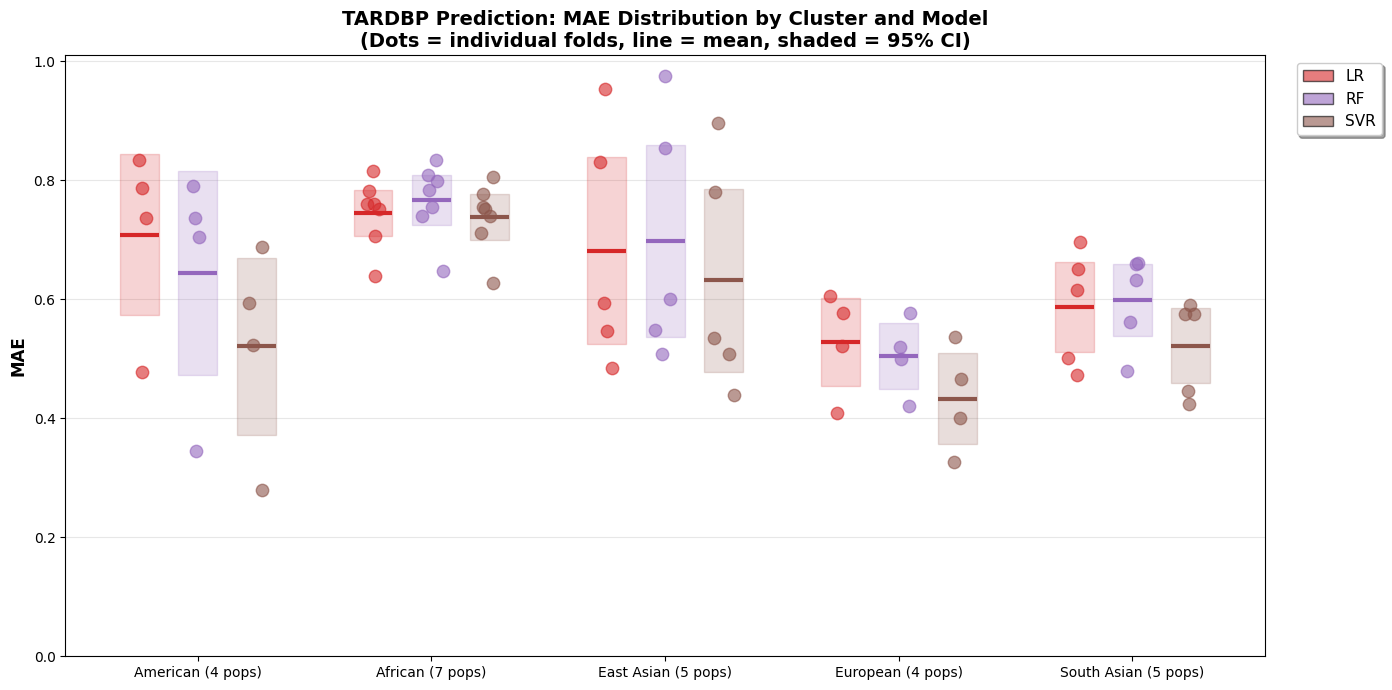

In [12]:
# Plot MAE with Distribution (Dot Plot + Mean + CI)
fig, ax = plt.subplots(figsize=(14, 7))

# Different color scheme for MAE plot
mae_colors = {'LinearRegression': '#d62728', 'RandomForestRegressor': '#9467bd', 'SVR': '#8c564b'}
model_labels = {'LinearRegression': 'LR', 'RandomForestRegressor': 'RF', 'SVR': 'SVR'}

model_names = results_df['model'].unique()
clusters_sorted = sorted(clusters.keys())
n_clusters = len(clusters_sorted)
n_models = len(model_names)
width = 0.25

# Plot for each cluster and model
for i, cluster_id in enumerate(clusters_sorted):
    for j, model in enumerate(model_names):
        # Get all MAE values for this cluster and model
        data = results_df[(results_df['cluster'] == cluster_id) & 
                         (results_df['model'] == model)]['mae'].values
        
        # Calculate statistics
        mean_val = np.mean(data)
        std_val = np.std(data)
        n = len(data)
        # 95% confidence interval
        ci = 1.96 * std_val / np.sqrt(n)
        
        # Position
        x = i + j * width
        color = mae_colors.get(model, '#333333')
        
        # Add jitter to x for individual points
        np.random.seed(42 + i * 10 + j)  # Reproducible jitter
        x_jitter = x + np.random.normal(0, width * 0.08, size=len(data))
        
        # Plot individual fold results as dots
        ax.scatter(x_jitter, data, s=80, alpha=0.6, color=color, zorder=3)
        
        # Plot mean line
        ax.hlines(mean_val, x - width/3, x + width/3, colors=color, linewidth=3, zorder=4)
        
        # Plot shaded CI region
        ax.fill_between([x - width/3, x + width/3], mean_val - ci, mean_val + ci, 
                         color=color, alpha=0.2, zorder=2)

# Set labels and formatting
ax.set_ylabel('MAE', fontsize=12, fontweight='bold')
ax.set_title(f'{target_gene} Prediction: MAE Distribution by Cluster and Model\n(Dots = individual folds, line = mean, shaded = 95% CI)', 
             fontsize=14, fontweight='bold')

# Set x-axis ticks at cluster centers
cluster_centers = [i + width for i in range(n_clusters)]
ax.set_xticks(cluster_centers)
ax.set_xticklabels([cluster_labels[c] for c in clusters_sorted], fontsize=10)

# Create custom legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=mae_colors[model], alpha=0.6, 
                         edgecolor='black', label=model_labels[model]) 
                  for model in model_names]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), 
          frameon=True, shadow=True, fontsize=11)

ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

# Save data for figure 4

In [13]:
import os


# Prepare data for leave-one-population-out (within cluster) approach
# This approach trains on all populations in a cluster except one, tests on the left-out population
lopo_data = results_df[['gene', 'model', 'rmse', 'mae', 'cluster', 'test_population']].copy()
lopo_data['approach'] = 'CP-ALS(k=5)'
lopo_data['pair'] = lopo_data['test_population']  # Use test population as identifier

# Create data4boxplots directory if it doesn't exist
# output_dir = 'data4boxplots'
# os.makedirs(output_dir, exist_ok=True)

# Save the data with consistent structure for later comparison (figure 4)
# output_file = os.path.join(output_dir, f'k5_cluster_{target_gene}_cpals_data_dotplot.csv')
# lopo_data.to_csv(output_file, index=False)
# print(f"CP-ALS(k=5) data saved to: {output_file}")
print(f"  Rows: {len(lopo_data)}")
print(f"  Columns: {list(lopo_data.columns)}")

# Display sample of data
print("\nSample of data:")
print(lopo_data.head(10))

# Display summary statistics
print("\nData summary by cluster and model:")
summary = lopo_data.groupby(['cluster', 'model']).agg({
    'rmse': ['count', 'mean', 'std'],
    'mae': ['mean', 'std']
}).round(3)
print(summary)

print("\nOverall summary by model:")
overall_summary = lopo_data.groupby('model').agg({
    'rmse': ['count', 'mean', 'std'],
    'mae': ['mean', 'std']
}).round(3)
print(overall_summary)

  Rows: 75
  Columns: ['gene', 'model', 'rmse', 'mae', 'cluster', 'test_population', 'approach', 'pair']

Sample of data:
     gene                  model      rmse       mae  cluster test_population  \
0  TARDBP       LinearRegression  1.338721  0.786716        0             CLM   
1  TARDBP  RandomForestRegressor  1.302932  0.704087        0             CLM   
2  TARDBP                    SVR  1.172957  0.522952        0             CLM   
3  TARDBP       LinearRegression  1.458634  0.833118        0             MXL   
4  TARDBP  RandomForestRegressor  1.427807  0.790328        0             MXL   
5  TARDBP                    SVR  1.381934  0.687465        0             MXL   
6  TARDBP       LinearRegression  0.756427  0.476839        0             PEL   
7  TARDBP  RandomForestRegressor  0.718098  0.344727        0             PEL   
8  TARDBP                    SVR  0.650914  0.279098        0             PEL   
9  TARDBP       LinearRegression  1.064215  0.736031        0       